In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, randint

In [2]:
df = pd.read_csv("../data/processed/match_features_v1")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34549 entries, 0 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34549 non-null  int64  
 1   date                  34549 non-null  object 
 2   home_team             34549 non-null  object 
 3   away_team             34549 non-null  object 
 4   home_score            34549 non-null  float64
 5   away_score            34549 non-null  float64
 6   city                  34549 non-null  object 
 7   country               34549 non-null  object 
 8   neutral               34549 non-null  bool   
 9   tournament_code       29840 non-null  object 
 10  tournament            29840 non-null  object 
 11  home_elo              29840 non-null  float64
 12  away_elo              29840 non-null  float64
 13  home_ranking          29840 non-null  float64
 14  away_ranking          29840 non-null  float64
 15  match_id           

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
match_id = df.pop("match_id")
df.insert(0, "match_id", match_id)

In [6]:
df.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,249.0,9.0,1.0,0.0,2.8,1.0,0.6,0.0,1.8,0.6
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,-111.0,-2.0,1.0,0.0,2.6,0.2,1.0,0.0,2.2,0.2
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,-126.0,-2.0,0.8,0.0,1.8,0.8,1.0,0.0,2.8,1.2
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,-55.0,-1.0,0.8,0.2,2.0,0.6,0.8,0.2,2.0,1.2
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,86.0,1.0,1.0,0.0,1.8,0.2,1.0,0.0,2.8,1.4


In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34549 entries, 0 to 34548
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              34549 non-null  int64         
 1   date                  34549 non-null  datetime64[ns]
 2   home_team             34549 non-null  object        
 3   away_team             34549 non-null  object        
 4   home_score            34549 non-null  float64       
 5   away_score            34549 non-null  float64       
 6   city                  34549 non-null  object        
 7   country               34549 non-null  object        
 8   neutral               34549 non-null  bool          
 9   tournament_code       29840 non-null  object        
 10  tournament            29840 non-null  object        
 11  home_elo              29840 non-null  float64       
 12  away_elo              29840 non-null  float64       
 13  home_ranking    

In [9]:
df.head(5)

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding
0,0,1872-11-30,Scotland,England,0.0,0.0,Glasgow,Scotland,False,F,...,-6.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1873-03-08,England,Scotland,4.0,2.0,London,England,False,F,...,28.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1874-03-07,Scotland,England,2.0,1.0,Glasgow,Scotland,False,F,...,-12.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1875-03-06,England,Scotland,2.0,2.0,London,England,False,F,...,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1876-03-04,Scotland,England,3.0,0.0,Glasgow,Scotland,False,F,...,20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df["target"] = ""

df.loc[df["home_score"] > df["away_score"], "target"] = "home_win"
df.loc[df["home_score"] == df["away_score"], "target"] = "draw"
df.loc[df["home_score"] < df["away_score"], "target"] = "away_win"

In [11]:
df[df["target"] == ""]

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target


In [12]:
df["target"].value_counts() 

target
home_win    16895
away_win     9503
draw         8151
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

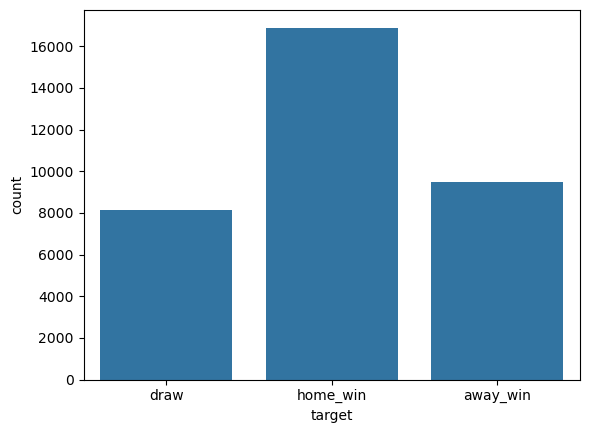

In [13]:
sns.countplot(data=df, x = "target")

In [14]:
df_2000 = df.copy() 

df_2000 = df_2000[df_2000["date"] >= "2000-01-01"]

df_2000.shape



(19119, 26)

In [15]:
df_2000 = df.copy() 
df_2000 = df_2000[df_2000["date"] >= "2000-01-01"]

df_1980 = df.copy()
df_1980 = df_1980[df_1980["date"] >= "1980-01-01"]

In [16]:
df_2000 = df_2000.sort_values(by="date")
df_1980 = df_1980.sort_values(by="date") 

In [17]:
n_2000 = len(df_2000)  # set the length to the length of the df
date_2000_70 = int(n_2000 * 0.70) #then 70% is allocated to training 
date_2000_85 = int(n_2000 * 0.85)  #15 % validate 

n_1980 = len(df_1980)
date_1980_70 = int(n_1980 * 0.70)
date_1980_85 = int(n_1980 * 0.85)


In [18]:
row_70 = df_2000.iloc[date_2000_70]["date"]
print(f" 70% for 2000 dataset is: {row_70}")
row_85 = df_2000.iloc[date_2000_85]["date"]
print(f" 85% for 2000 dataset is: {row_85}") 


 70% for 2000 dataset is: 2018-02-28 00:00:00
 85% for 2000 dataset is: 2022-09-21 00:00:00


In [19]:
row_70_1980 = df_1980.iloc[date_1980_70]["date"]
print(f" 70% for 1980 dataset is: {row_70_1980}")
row_85_1980 = df_1980.iloc[date_1980_85]["date"]
print(f" 85% for 1980 dataset is: {row_85_1980}") 

 70% for 1980 dataset is: 2014-10-11 00:00:00
 85% for 1980 dataset is: 2021-03-27 00:00:00


In [20]:
df_1980.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27381 entries, 7168 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              27381 non-null  int64         
 1   date                  27381 non-null  datetime64[ns]
 2   home_team             27381 non-null  object        
 3   away_team             27381 non-null  object        
 4   home_score            27381 non-null  float64       
 5   away_score            27381 non-null  float64       
 6   city                  27381 non-null  object        
 7   country               27381 non-null  object        
 8   neutral               27381 non-null  bool          
 9   tournament_code       24862 non-null  object        
 10  tournament            24862 non-null  object        
 11  home_elo              24862 non-null  float64       
 12  away_elo              24862 non-null  float64       
 13  home_ranking      

In [21]:
df_2000.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19119 entries, 15430 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              19119 non-null  int64         
 1   date                  19119 non-null  datetime64[ns]
 2   home_team             19119 non-null  object        
 3   away_team             19119 non-null  object        
 4   home_score            19119 non-null  float64       
 5   away_score            19119 non-null  float64       
 6   city                  19119 non-null  object        
 7   country               19119 non-null  object        
 8   neutral               19119 non-null  bool          
 9   tournament_code       17957 non-null  object        
 10  tournament            17957 non-null  object        
 11  home_elo              17957 non-null  float64       
 12  away_elo              17957 non-null  float64       
 13  home_ranking     

In [22]:
df_1980["abs_rank_diff"] = df_1980["rank_difference"].copy() 
df_1980["abs_elo_diff"] = df_1980["elo_difference"].copy()

df_2000["abs_rank_diff"] = df_2000["rank_difference"].copy() 
df_2000["abs_elo_diff"] = df_2000["elo_difference"].copy()

df_1980["abs_rank_diff"] = df_1980["rank_difference"].abs()
df_1980["abs_elo_diff"] = df_1980["elo_difference"].abs() 

df_2000["abs_rank_diff"] = df_2000["rank_difference"].abs()
df_2000["abs_elo_diff"] = df_2000["elo_difference"].abs()


In [23]:
closeness = [0.90, 0.80, 0.65, 0.55, 0.35, 0.25, 0.15, 0.05]

condition_1980 = [

    (df_1980["abs_rank_diff"] <= 25), # 0.90 
    (df_1980["abs_rank_diff"] > 25) & (df_1980["abs_rank_diff"] <= 50), #26 - 50 = 0.80f
    (df_1980["abs_rank_diff"] > 50) & (df_1980["abs_rank_diff"] <= 75),  #51 - 75 = 0.65
    (df_1980["abs_rank_diff"] > 75) & (df_1980["abs_rank_diff"] <= 100), #76 - 100 = 0.55 
    (df_1980["abs_rank_diff"] > 100) & (df_1980["abs_rank_diff"] <= 125),  #101 - 125 = 0.35 
    (df_1980["abs_rank_diff"] > 125) & (df_1980["abs_rank_diff"] <= 150), #126 - 150 = 0.25 
    (df_1980["abs_rank_diff"] > 150) & (df_1980["abs_rank_diff"] <= 175), #151- 175 = 0.15
    (df_1980["abs_rank_diff"] > 175) # 176+  0.05
]

condition_2000 = [

    (df_2000["abs_rank_diff"] <= 25), # 0.90 
    (df_2000["abs_rank_diff"] > 25) & (df_2000["abs_rank_diff"] <= 50), #26 - 50 = 0.80f
    (df_2000["abs_rank_diff"] > 50) & (df_2000["abs_rank_diff"] <= 75),  #51 - 75 = 0.65
    (df_2000["abs_rank_diff"] > 75) & (df_2000["abs_rank_diff"] <= 100), #76 - 100 = 0.55 
    (df_2000["abs_rank_diff"] > 100) & (df_2000["abs_rank_diff"] <= 125),  #101 - 125 = 0.35 
    (df_2000["abs_rank_diff"] > 125) & (df_2000["abs_rank_diff"] <= 150), #126 - 150 = 0.25 
    (df_2000["abs_rank_diff"] > 150) & (df_2000["abs_rank_diff"] <= 175), #151- 175 = 0.15
    (df_2000["abs_rank_diff"] > 175) # 176+  0.05
]

df_1980["similarity_scale"] = np.select(condition_1980, closeness)
df_2000["similarity_scale"] = np.select(condition_2000, closeness) 


In [24]:
train_date = "2018-01-01"
val_date = "2022-01-01" 

train_data_2000 = df_2000[(df_2000["date"]) < train_date]
val_data_2000 = df_2000[(df_2000["date"] >= train_date) & (df_2000["date"] < val_date)]
test_data_2000 = df_2000[(df_2000["date"] >= val_date)]

train_data_1980 = df_1980[(df_1980["date"]) < train_date]
val_data_1980 = df_1980[(df_1980["date"] >= train_date) & (df_1980["date"] < val_date)]
test_data_1980 = df_1980[(df_1980["date"] >= val_date)]

shape_2000_train = train_data_2000.shape
shape_2000_val = val_data_2000.shape
shape_2000_test = test_data_2000.shape

shape_1980_train = train_data_1980.shape
shape_1980_val = val_data_1980.shape
shape_1980_test = test_data_1980.shape

print(f"2000s training data: {shape_2000_train}")
print(f"2000s validation data: {shape_2000_val}")
print(f"2000s test data: {shape_2000_test}")
print("\n") 
print(f"1980s training data: {shape_1980_train}")
print(f"1980s validation data: {shape_1980_val}")
print(f"1980s test data: {shape_1980_test}")

2000s training data: (13371, 29)
2000s validation data: (2492, 29)
2000s test data: (3256, 29)


1980s training data: (21633, 29)
1980s validation data: (2492, 29)
1980s test data: (3256, 29)


In [25]:
train_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
28796,28796,2017-12-05,Taiwan,Laos,2.0,0.0,Taipei,Taiwan,False,NaN,...,2.6,1.2,0.2,0.6,0.8,2.6,home_win,NaN,NaN,0.00
28797,28797,2017-12-06,Indonesia,Kyrgyzstan,0.0,1.0,Banda Aceh,Indonesia,False,NaN,...,1.8,0.6,0.4,0.2,1.8,0.6,away_win,NaN,NaN,0.00
28798,28798,2017-12-14,Qatar,Liechtenstein,1.0,2.0,Doha,Qatar,False,F,...,1.2,1.4,0.0,1.0,0.0,4.0,away_win,75.0,290.0,0.65
28799,28799,2017-12-18,Bahrain,Kuwait,0.0,0.0,Riffa,Bahrain,False,F,...,2.2,0.4,0.4,0.4,2.2,0.8,draw,20.0,68.0,0.90
28800,28800,2017-12-25,Jordan,Libya,1.0,1.0,Amman,Jordan,False,F,...,1.6,0.8,0.4,0.4,1.8,1.2,draw,4.0,9.0,0.90


In [26]:
val_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
31288,31288,2021-12-08,Mexico,Chile,2.0,2.0,Austin,United States,True,F,...,1.6,1.4,0.6,0.4,1.2,0.8,draw,7.0,49.0,0.90
31289,31289,2021-12-09,Tanzania,Uganda,0.0,2.0,Dar es Salaam,Tanzania,False,F,...,1.0,1.4,0.4,0.2,0.6,0.4,away_win,42.0,151.0,0.80
31290,31290,2021-12-11,El Salvador,Chile,0.0,1.0,Los Angeles,United States,True,F,...,0.6,1.4,0.6,0.2,1.6,0.8,away_win,56.0,294.0,0.65
31291,31291,2021-12-18,United States,Bosnia and Herzegovina,1.0,0.0,Los Angeles,United States,False,F,...,1.4,0.6,0.2,0.4,1.2,1.6,home_win,49.0,258.0,0.80
31292,31292,2021-12-30,Sudan,Ethiopia,2.0,3.0,Limbé,Cameroon,True,F,...,1.0,2.0,0.2,0.4,0.8,1.2,away_win,13.0,37.0,0.90


In [27]:
test_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,2.8,1.0,0.6,0.0,1.8,0.6,home_win,9.0,249.0,0.9
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,2.6,0.2,1.0,0.0,2.2,0.2,away_win,2.0,111.0,0.9
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,1.8,0.8,1.0,0.0,2.8,1.2,away_win,2.0,126.0,0.9
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,2.0,0.6,0.8,0.2,2.0,1.2,away_win,1.0,55.0,0.9
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,1.8,0.2,1.0,0.0,2.8,1.4,home_win,1.0,86.0,0.9


In [28]:
train_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
28796,28796,2017-12-05,Taiwan,Laos,2.0,0.0,Taipei,Taiwan,False,NaN,...,2.6,1.2,0.2,0.6,0.8,2.6,home_win,NaN,NaN,0.00
28797,28797,2017-12-06,Indonesia,Kyrgyzstan,0.0,1.0,Banda Aceh,Indonesia,False,NaN,...,1.8,0.6,0.4,0.2,1.8,0.6,away_win,NaN,NaN,0.00
28798,28798,2017-12-14,Qatar,Liechtenstein,1.0,2.0,Doha,Qatar,False,F,...,1.2,1.4,0.0,1.0,0.0,4.0,away_win,75.0,290.0,0.65
28799,28799,2017-12-18,Bahrain,Kuwait,0.0,0.0,Riffa,Bahrain,False,F,...,2.2,0.4,0.4,0.4,2.2,0.8,draw,20.0,68.0,0.90
28800,28800,2017-12-25,Jordan,Libya,1.0,1.0,Amman,Jordan,False,F,...,1.6,0.8,0.4,0.4,1.8,1.2,draw,4.0,9.0,0.90


In [29]:
val_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
31288,31288,2021-12-08,Mexico,Chile,2.0,2.0,Austin,United States,True,F,...,1.6,1.4,0.6,0.4,1.2,0.8,draw,7.0,49.0,0.90
31289,31289,2021-12-09,Tanzania,Uganda,0.0,2.0,Dar es Salaam,Tanzania,False,F,...,1.0,1.4,0.4,0.2,0.6,0.4,away_win,42.0,151.0,0.80
31290,31290,2021-12-11,El Salvador,Chile,0.0,1.0,Los Angeles,United States,True,F,...,0.6,1.4,0.6,0.2,1.6,0.8,away_win,56.0,294.0,0.65
31291,31291,2021-12-18,United States,Bosnia and Herzegovina,1.0,0.0,Los Angeles,United States,False,F,...,1.4,0.6,0.2,0.4,1.2,1.6,home_win,49.0,258.0,0.80
31292,31292,2021-12-30,Sudan,Ethiopia,2.0,3.0,Limbé,Cameroon,True,F,...,1.0,2.0,0.2,0.4,0.8,1.2,away_win,13.0,37.0,0.90


In [30]:
test_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,2.8,1.0,0.6,0.0,1.8,0.6,home_win,9.0,249.0,0.9
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,2.6,0.2,1.0,0.0,2.2,0.2,away_win,2.0,111.0,0.9
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,1.8,0.8,1.0,0.0,2.8,1.2,away_win,2.0,126.0,0.9
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,2.0,0.6,0.8,0.2,2.0,1.2,away_win,1.0,55.0,0.9
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,1.8,0.2,1.0,0.0,2.8,1.4,home_win,1.0,86.0,0.9


In [31]:
test_data_2000.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 3256 entries, 31293 to 34548
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              3256 non-null   int64         
 1   date                  3256 non-null   datetime64[ns]
 2   home_team             3256 non-null   object        
 3   away_team             3256 non-null   object        
 4   home_score            3256 non-null   float64       
 5   away_score            3256 non-null   float64       
 6   city                  3256 non-null   object        
 7   country               3256 non-null   object        
 8   neutral               3256 non-null   bool          
 9   tournament_code       3142 non-null   object        
 10  tournament            3142 non-null   object        
 11  home_elo              3142 non-null   float64       
 12  away_elo              3142 non-null   float64       
 13  home_ranking      

In [32]:
eda_df = train_data_2000.copy()

eda_df = eda_df.drop(columns = [
    "match_id", "city", "country", 
    "tournament_code", "neutral"
    ""
])

avg_elo_draw = eda_df.loc[eda_df["target"] == "draw", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in draws: {avg_elo_draw:.2f}")
avg_rank_draw = eda_df.loc[eda_df["target"] == "draw", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in draws: {avg_rank_draw:.2f}")

print("\n")

avg_elo_hwin = eda_df.loc[eda_df["target"] == "home_win", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in home wins: {avg_elo_hwin:.2f}")
avg_rank_hwin = eda_df.loc[eda_df["target"] == "home_win", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in home wins: {avg_rank_hwin:.2f}")

print("\n")

avg_elo_awin = eda_df.loc[eda_df["target"] == "away_win", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in away wins: {avg_elo_awin:.2f}")
avg_rank_awin = eda_df.loc[eda_df["target"] == "away_win", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in home wins: {avg_rank_awin:.2f}")

      

average elo difference for matches that ended in draws: 154.41
average rank difference for matches that ended in draws: 30.56


average elo difference for matches that ended in home wins: 228.47
average rank difference for matches that ended in home wins: 44.65


average elo difference for matches that ended in away wins: 253.68
average rank difference for matches that ended in home wins: 49.56


In [33]:
eda_df["abs_rank_diff"] = eda_df["rank_difference"].copy() 
eda_df["abs_elo_diff"] = eda_df["elo_difference"].copy()

eda_df["abs_rank_diff"] = eda_df["abs_rank_diff"].abs()
eda_df["abs_elo_diff"] = eda_df["abs_elo_diff"].abs()

eda_df["draw_flag"] = eda_df["target"].copy()

eda_df.loc[(eda_df["draw_flag"] == "home_win") | (eda_df["draw_flag"] == "away_win"), "draw_flag"] = 0 
eda_df.loc[(eda_df["draw_flag"] == "draw"), "draw_flag"] = 1

eda_df["draw_flag"] = eda_df["draw_flag"].astype(int) 


In [34]:
eda_df.shape

(13371, 25)

In [35]:
eda_df["abs_elo_diff"].max() 

eda_df[eda_df["abs_elo_diff"].between(501, 700)].count()

date                    652
home_team               652
away_team               652
home_score              652
away_score              652
tournament              652
home_elo                652
away_elo                652
home_ranking            652
away_ranking            652
elo_difference          652
rank_difference         652
home_last5_W            645
home_last5_L            645
home_last5_scoring      645
home_last5_conceding    645
away_last5_W            644
away_last5_L            644
away_last5_scoring      644
away_last5_conceding    644
target                  652
abs_rank_diff           652
abs_elo_diff            652
similarity_scale        652
draw_flag               652
dtype: int64

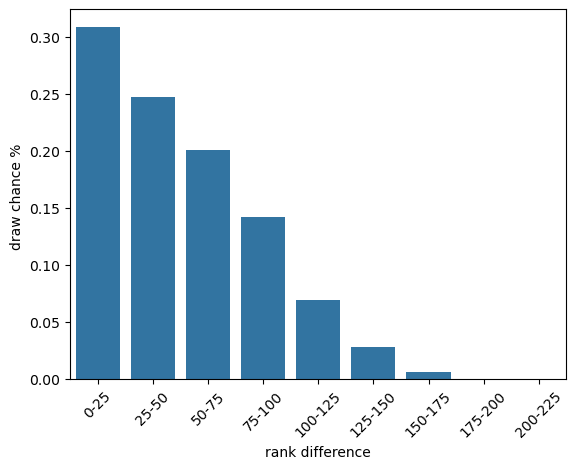

In [36]:
rank_bins = range(0, 250, 25)
rank_labels = [f'{i}-{i+25}' for i in range(0, 225, 25)]


eda_df["bins_rank"] = pd.cut(eda_df["abs_rank_diff"], bins = rank_bins, labels = rank_labels)
sns.barplot(data = eda_df, x = "bins_rank", y = "draw_flag", errorbar = None)
plt.xticks(rotation=45)
plt.xlabel("rank difference")
plt.ylabel("draw chance % ")
plt.show() 



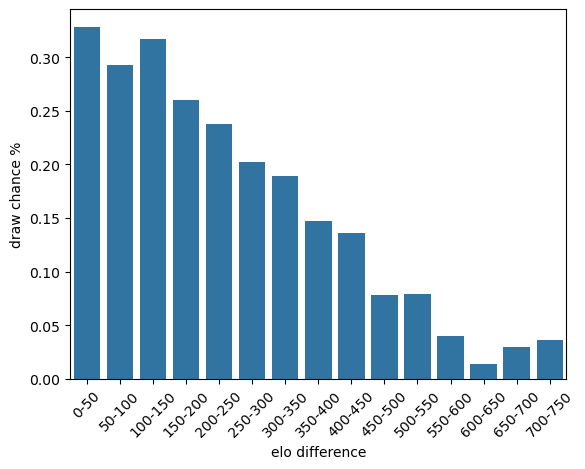

In [37]:
elo_bins = range(0, 800, 50)
elo_labels = [f'{i}-{i+50}' for i in range(0, 750, 50)]


eda_df["bins_elo"] = pd.cut(eda_df["abs_elo_diff"], bins = elo_bins, labels = elo_labels)
sns.barplot(data = eda_df, x = "bins_elo", y = "draw_flag", errorbar = None)
plt.xticks(rotation=45)
plt.xlabel("elo difference")
plt.ylabel("draw chance %")
plt.show() 


In [38]:
closeness = [0.90, 0.80, 0.65, 0.55, 0.35, 0.25, 0.15, 0.05]

condition = [

    (eda_df["abs_rank_diff"] <= 25), # 0.90 
    (eda_df["abs_rank_diff"] > 25) & (eda_df["abs_rank_diff"] <= 50), #26 - 50 = 0.80
    (eda_df["abs_rank_diff"] > 50) & (eda_df["abs_rank_diff"] <= 75),  #51 - 75 = 0.65
    (eda_df["abs_rank_diff"] > 75) & (eda_df["abs_rank_diff"] <= 100), #76 - 100 = 0.55 
    (eda_df["abs_rank_diff"] > 100) & (eda_df["abs_rank_diff"] <= 125),  #101 - 125 = 0.35 
    (eda_df["abs_rank_diff"] > 125) & (eda_df["abs_rank_diff"] <= 150), #126 - 150 = 0.25 
    (eda_df["abs_rank_diff"] > 150) & (eda_df["abs_rank_diff"] <= 175), #151- 175 = 0.15
    (eda_df["abs_rank_diff"] > 175) # 176+  0.05
]


eda_df["similarity_scale"] = np.select(condition, closeness)

In [39]:
eda_df.head(5) 

,date,home_team,away_team,home_score,away_score,tournament,home_elo,away_elo,home_ranking,away_ranking,...,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale,draw_flag,bins_rank,bins_elo
15430,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,1630.0,1334.0,50.0,122.0,...,0.8,0.8,1.8,home_win,72.0,296.0,0.65,0,50-75,250-300
15431,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,1648.0,1330.0,44.0,122.0,...,0.8,0.8,1.8,home_win,78.0,318.0,0.55,0,75-100,300-350
15432,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,1580.0,1570.0,59.0,62.0,...,0.2,1.0,0.8,draw,3.0,10.0,0.90,1,0-25,0-50
15433,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,1421.0,1459.0,102.0,90.0,...,0.4,1.2,1.6,draw,12.0,38.0,0.90,1,0-25,0-50
15434,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1551.0,1375.0,68.0,113.0,...,0.6,1.0,1.4,draw,45.0,176.0,0.80,1,25-50,150-200


In [40]:
test_data_2000[test_data_2000["target"] == "draw"]

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,abs_rank_diff,abs_elo_diff,similarity_scale
31294,31294,2022-01-02,Sudan,Zimbabwe,0.0,0.0,Yaoundé,Cameroon,True,F,...,1.0,1.8,0.0,0.8,0.4,1.4,draw,1.0,2.0,0.90
31304,31304,2022-01-11,Sudan,Guinea-Bissau,0.0,0.0,Garoua,Cameroon,True,AR,...,0.8,1.6,0.2,0.4,0.8,2.0,draw,23.0,67.0,0.90
31305,31305,2022-01-11,Algeria,Sierra Leone,0.0,0.0,Douala,Cameroon,True,AR,...,3.8,0.6,0.4,0.0,0.8,0.4,draw,85.0,429.0,0.55
31306,31306,2022-01-12,Iceland,Uganda,1.0,1.0,Belek,Turkey,True,F,...,1.2,1.6,0.6,0.2,1.0,0.4,draw,17.0,84.0,0.90
31311,31311,2022-01-14,Senegal,Guinea,0.0,0.0,Bafoussam,Cameroon,True,AR,...,2.2,0.6,0.4,0.4,0.6,1.2,draw,49.0,258.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34513,34513,2026-06-27,Colombia,Portugal,0.0,0.0,Miami Gardens,United States,True,WC,...,2.0,1.0,0.8,0.0,2.4,0.6,draw,1.0,14.0,0.90
34519,34519,2026-06-29,Germany,Paraguay,1.0,1.0,Foxborough,United States,True,WC,...,3.2,1.0,0.4,0.4,1.4,1.2,draw,12.0,85.0,0.90
34520,34520,2026-06-29,Netherlands,Morocco,1.0,1.0,Guadalupe,Mexico,True,WC,...,2.4,1.2,0.6,0.0,2.2,0.8,draw,8.0,85.0,0.90
34530,34530,2026-07-03,Australia,Egypt,1.0,1.0,Arlington,United States,True,WC,...,0.6,0.8,0.4,0.2,1.4,1.0,draw,7.0,48.0,0.90


In [41]:
df_2000.shape

(19119, 29)

In [42]:
train_data_2000 = train_data_2000.dropna() 
val_data_2000 = val_data_2000.dropna()
test_data_2000 = test_data_2000.dropna()


train_data_1980 = train_data_1980.dropna()
val_data_1980 = val_data_1980.dropna()
test_data_1980 = test_data_1980.dropna()


In [43]:
X_train_2000 = train_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]         

X_val_2000 = val_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]

X_test_2000 = test_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]



In [44]:
y_train_2000 = train_data_2000["target"]
y_val_2000 = val_data_2000["target"]
y_test_2000 = test_data_2000["target"]


In [45]:
X_train_1980 = train_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]         

X_val_1980 = val_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]

X_test_1980 = test_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral"]]


dummy_df = X_val_1980.copy() 


In [46]:
y_train_1980 = train_data_1980["target"]
y_val_1980 = val_data_1980["target"]
y_test_1980 = test_data_1980["target"]


In [47]:
print("2000\n" )
print(f"train check: X={X_train_2000.shape}, y={y_train_2000.shape} ")
print(f"val check: X={X_val_2000.shape}, y={y_val_2000.shape} ")
print(f"test check: X={X_test_2000.shape}, y={y_test_2000.shape} ")


2000

train check: X=(12374, 15), y=(12374,) 
val check: X=(2392, 15), y=(2392,) 
test check: X=(3142, 15), y=(3142,) 


In [48]:
print("1980\n" )
print(f"train check: X={X_train_1980.shape}, y={y_train_1980.shape} ")
print(f"val check: X={X_val_1980.shape}, y={y_val_1980.shape} ")
print(f"test check: X={X_test_1980.shape}, y={y_test_1980.shape} ")


1980

train check: X=(19178, 15), y=(19178,) 
val check: X=(2392, 15), y=(2392,) 
test check: X=(3142, 15), y=(3142,) 


In [49]:
scaler_1980 = StandardScaler()
scaler_2000 = StandardScaler() 

modelLR_1980 = LogisticRegression() 
modelLR_2000 = LogisticRegression()

X_train_1980 = scaler_1980.fit_transform(X_train_1980)
X_val_1980 = scaler_1980.transform(X_val_1980) 

X_train_2000 = scaler_2000.fit_transform(X_train_2000)
X_val_2000 = scaler_2000.transform(X_val_2000)

modelLR_1980.fit(X_train_1980, y_train_1980)
modelLR_2000.fit(X_train_2000, y_train_2000) 

lr_pred_1980 = modelLR_1980.predict(X_val_1980) 
lr_pred_2000 = modelLR_2000.predict(X_val_2000)

In [50]:
lr_1980_acc = accuracy_score(y_val_1980, lr_pred_1980)
lr_2000_acc = accuracy_score(y_val_2000, lr_pred_2000) 

lr_1980_prc = precision_score(y_val_1980, lr_pred_1980, average = "macro")
lr_2000_prc = precision_score(y_val_2000, lr_pred_2000, average = "macro") 

lr_1980_rec = recall_score(y_val_1980, lr_pred_1980, average = "macro") 
lr_2000_rec = recall_score(y_val_2000, lr_pred_2000, average = "macro") 

lr_1980_f1 = f1_score(y_val_1980, lr_pred_1980, average = "macro")
lr_2000_f1 = f1_score(y_val_2000, lr_pred_2000, average = "macro" )

lr_matrix_1980 = confusion_matrix(y_val_1980, lr_pred_1980) 
lr_matrix_2000 = confusion_matrix(y_val_2000, lr_pred_2000)

lr_class_1980 = classification_report(y_val_1980, lr_pred_1980)
lr_class_2000 = classification_report(y_val_2000, lr_pred_2000)

print("\t 1980")
print(f"accuracy score: {lr_1980_acc:.2f}")
print(f"precision score: {lr_1980_prc:.2f}")
print(f"recall score: {lr_1980_rec:.2f}")
print(f"f1 score: {lr_1980_f1:.2f}")
print("\n")
print(lr_class_1980)
print(lr_matrix_1980) 

	 1980
accuracy score: 0.66
precision score: 0.55
recall score: 0.56
f1 score: 0.51


              precision    recall  f1-score   support

    away_win       0.68      0.74      0.71       681
        draw       0.31      0.03      0.06       563
    home_win       0.66      0.91      0.77      1148

    accuracy                           0.66      2392
   macro avg       0.55      0.56      0.51      2392
weighted avg       0.58      0.66      0.58      2392

[[ 503   22  156]
 [ 159   19  385]
 [  80   20 1048]]


In [51]:
print("\t 2000")
print(f"accuracy score: {lr_2000_acc:.2f}")
print(f"precision score: {lr_2000_prc:.2f}")
print(f"recall score: {lr_2000_rec:.2f}")
print(f"f1 score: {lr_2000_f1:.2f}")
print("\n")
print(lr_class_2000)
print(lr_matrix_2000) 

	 2000
accuracy score: 0.66
precision score: 0.56
recall score: 0.56
f1 score: 0.51


              precision    recall  f1-score   support

    away_win       0.67      0.75      0.70       681
        draw       0.35      0.03      0.06       563
    home_win       0.66      0.91      0.76      1148

    accuracy                           0.66      2392
   macro avg       0.56      0.56      0.51      2392
weighted avg       0.59      0.66      0.58      2392

[[ 510   16  155]
 [ 166   18  379]
 [  90   18 1040]]


In [52]:
modelLR_1980.classes_

array(['away_win', 'draw', 'home_win'], dtype=object)

In [53]:
prob_1980 = modelLR_1980.predict_proba(X_val_1980)
modelLR_1980.classes_
print(prob_1980)

[[0.75765808 0.20191585 0.04042606]
 [0.54784805 0.29476276 0.15738919]
 [0.88933138 0.10244363 0.00822498]
 ...
 [0.69297642 0.22978538 0.0772382 ]
 [0.03552519 0.1725371  0.7919377 ]
 [0.37529871 0.298612   0.32608929]]


In [54]:
see_probs = pd.DataFrame(prob_1980, columns=[f"Prob_Class_{c}" for c in modelLR_1980.classes_])
dummy_df  = dummy_df.reset_index(drop=True)
result_df = pd.concat([dummy_df, see_probs], axis = 1)


result_col = y_val_1980.copy() 
result_col = result_col.reset_index(drop=True) 


result_df = pd.concat([result_df, result_col], axis=1)

result_df.tail(15) 



,home_elo,away_elo,home_ranking,away_ranking,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,neutral,Prob_Class_away_win,Prob_Class_draw,Prob_Class_home_win,target
2377,1305.0,1272.0,132.0,139.0,33.0,7.0,0.0,0.8,0.2,1.6,0.2,0.8,0.4,2.2,True,0.245059,0.277897,0.477044,home_win
2378,1607.0,1646.0,61.0,50.0,-39.0,-11.0,0.8,0.2,2.2,0.6,0.8,0.0,2.0,0.4,False,0.194363,0.348013,0.457624,home_win
2379,1625.0,1413.0,57.0,99.0,212.0,42.0,0.6,0.0,1.8,0.6,0.4,0.4,1.2,1.2,False,0.045673,0.196584,0.757742,home_win
2380,1330.0,1359.0,123.0,111.0,-29.0,-12.0,0.4,0.6,0.6,1.2,0.2,0.6,1.0,1.4,False,0.217298,0.331019,0.451683,draw
2381,1719.0,1403.0,41.0,102.0,316.0,61.0,1.0,0.0,3.4,0.2,0.0,0.2,1.0,1.6,False,0.025340,0.144545,0.830115,home_win
2382,1380.0,1489.0,105.0,85.0,-109.0,-20.0,0.2,0.4,0.8,1.0,0.0,0.4,0.6,1.0,False,0.334589,0.354764,0.310647,away_win
2383,1573.0,1788.0,67.0,27.0,-215.0,-40.0,0.0,0.2,0.6,1.2,0.6,0.0,1.0,0.4,True,0.593101,0.279692,0.127206,away_win
2384,1643.0,1467.0,51.0,87.0,176.0,36.0,0.8,0.2,1.6,0.4,0.6,0.2,1.4,1.0,False,0.045768,0.206389,0.747843,draw
2385,1131.0,995.0,176.0,191.0,136.0,15.0,0.4,0.6,1.0,2.2,0.2,0.8,0.6,4.8,True,0.149591,0.210006,0.640403,home_win
2386,1502.0,1848.0,82.0,16.0,-346.0,-66.0,0.0,0.8,0.6,1.6,0.6,0.2,1.4,0.8,True,0.744137,0.200227,0.055636,draw


In [55]:
r_forest_1980 = RandomForestClassifier(random_state = 42) 
r_forest_2000 = RandomForestClassifier(random_state = 42) 

r_forest_1980.fit(X_train_1980, y_train_1980)
r_forest_2000.fit(X_train_2000, y_train_2000) 

pred_1980 = r_forest_1980.predict(X_val_1980)

pred_2000 = r_forest_2000.predict(X_val_2000) 

In [61]:
le = LabelEncoder()  # instantiate label encoder

train_copy_1980 = y_train_1980.copy()
train_copy_2000 = y_train_2000.copy()

val_copy_1980 = y_val_1980.copy()
val_copy_2000 = y_val_2000.copy()

encoded_train_1980 = le.fit_transform(train_copy_1980)
encoded_train_2000 = le.transform(train_copy_2000)

encoded_val_1980 = le.transform(val_copy_1980)
encoded_val_2000 = le.transform(val_copy_2000)


xgb_1980 = XGBClassifier(
    n_estimators=255,
    max_depth=4,
    learning_rate=0.158,
    objective="multi:softprob",
    eval_metric="logloss"
)

xgb_2000 = XGBClassifier(
    n_estimators=237,
    max_depth=3,
    learning_rate=0.167,
    objective="multi:softprob",
    eval_metric="logloss"
)


xgb_1980.fit(X_train_1980, encoded_train_1980)
xgb_2000.fit(X_train_2000, encoded_train_2000)


pred_xgb_1980 = xgb_1980.predict(X_val_1980)
pred_xgb_2000 = xgb_2000.predict(X_val_2000)

pred_xgb_1980_train = xgb_1980.predict(X_train_1980)
pred_xgb_2000_train = xgb_2000.predict(X_train_2000) 


print("\t classification report: (1980)")
print(classification_report(encoded_val_1980, pred_xgb_1980))

print("\n")

print("\t classification report: (2000)")
print(classification_report(encoded_val_2000, pred_xgb_2000))

	 classification report: (1980)
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       681
           1       0.32      0.12      0.17       563
           2       0.66      0.87      0.75      1148

    accuracy                           0.64      2392
   macro avg       0.56      0.56      0.54      2392
weighted avg       0.59      0.64      0.60      2392



	 classification report: (2000)
              precision    recall  f1-score   support

           0       0.68      0.69      0.68       681
           1       0.35      0.11      0.17       563
           2       0.66      0.88      0.76      1148

    accuracy                           0.64      2392
   macro avg       0.56      0.56      0.54      2392
weighted avg       0.59      0.64      0.60      2392



In [62]:
print("\t training classification report: (1980)")
print(classification_report(encoded_train_1980, pred_xgb_1980_train))

print("\n")

print("\t training classification report: (2000)")
print(classification_report(encoded_train_2000, pred_xgb_2000_train))

	 training classification report: (1980)
              precision    recall  f1-score   support

           0       0.67      0.70      0.69      5085
           1       0.61      0.28      0.38      4704
           2       0.71      0.89      0.79      9389

    accuracy                           0.69     19178
   macro avg       0.66      0.62      0.62     19178
weighted avg       0.68      0.69      0.66     19178



	 training classification report: (2000)
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      3379
           1       0.57      0.21      0.31      2974
           2       0.70      0.89      0.78      6021

    accuracy                           0.67     12374
   macro avg       0.64      0.60      0.59     12374
weighted avg       0.66      0.67      0.64     12374



In [58]:
tscv = TimeSeriesSplit(n_splits = 5) 

param_grid = {
    "learning_rate": uniform(0.01, 0.3),
    "n_estimators": randint(50, 500), 
    "max_depth": randint(2, 8) 
}


r_search = RandomizedSearchCV(
    estimator = xgb_1980,
    param_distributions = param_grid, 
    n_iter=20,
    cv=tscv, 
    scoring = "f1_macro", 
    n_jobs = -1,
    random_state = 42 
)

r_search.fit(X_train_1980, encoded_train_1980)
print("best hyper-parameters for 1980 xgb: ", r_search.best_params_)

best hyper-parameters for 1980 xgb:  {'learning_rate': np.float64(0.15855307303338106), 'max_depth': 4, 'n_estimators': 255}


In [59]:
r_search_2000 = RandomizedSearchCV(
    estimator = xgb_2000,
    param_distributions = param_grid, 
    n_iter=20,
    cv=tscv, 
    scoring = "f1_macro", 
    n_jobs = -1,
    random_state = 42 
)

r_search_2000.fit(X_train_2000, encoded_train_2000)
print("best hyper-parameters for 2000 xgb: ", r_search_2000.best_params_ )

best hyper-parameters for 2000 xgb:  {'learning_rate': np.float64(0.16743239807751675), 'max_depth': 3, 'n_estimators': 237}
